In [1]:
# =============================================================================
# 1. SETUP AND LOAD DATA
# =============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from tabulate import tabulate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from econml.dml import CausalForestDML
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# Set plotting style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
print("Loading feature-engineered data...")
df = pd.read_csv('../data/client_price_features.csv')
print("Data loaded successfully.")
print("Data shape:", df.shape)


Loading feature-engineered data...
Data loaded successfully.
Data shape: (14606, 57)



--- Starting Sub-Task 4.1: Propensity Score Matching ---
Propensity scores calculated.
Matching complete. Matched 514 treated customers with 514 control customers.


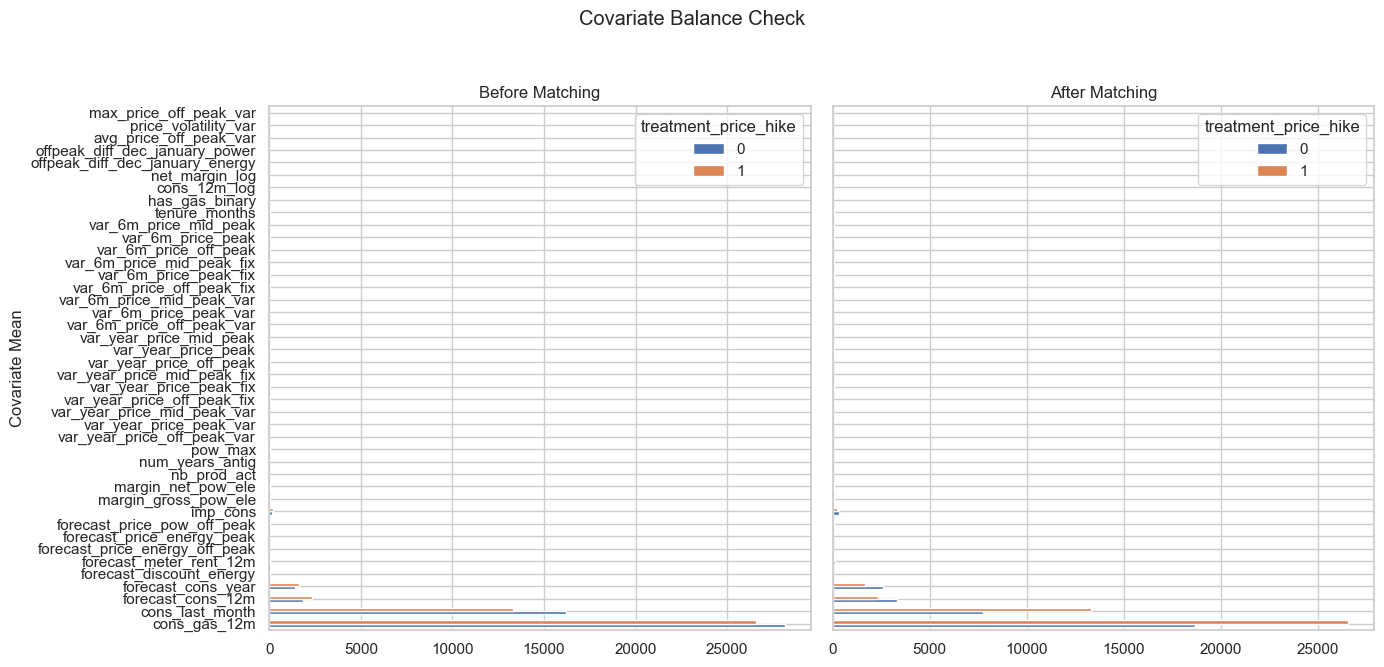

Balance check visualization generated. We should see smaller differences in the 'After Matching' plot.

Average Treatment Effect on the Treated (ATT) from PSM: 0.1284
Interpretation: Experiencing a price hike causes an estimated 12.84 percentage point increase in the probability of churning.


In [3]:
# =============================================================================
# SUB-TASK 4.1: PROPENSITY SCORE MATCHING (PSM)
# =============================================================================
print("\n--- Starting Sub-Task 4.1: Propensity Score Matching ---")

# --- 4.1.1 Define Variables and Train Propensity Model ---
# The treatment variable T
T = df['treatment_price_hike']
# The outcome variable Y
Y = df['churn']
# The covariates X (features to match on)
# We exclude the churn outcome, the treatment itself, and any post-treatment variables
numeric_df = df.select_dtypes(include=np.number)
X = numeric_df.drop(columns=['churn', 'treatment_price_hike', 'max_monthly_increase_pct'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a logistic regression model to predict the treatment (getting a price hike)
# This model estimates the propensity scores
propensity_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
propensity_model.fit(X_scaled, T) # Use the scaled data
propensity_scores = propensity_model.predict_proba(X_scaled)[:, 1] # Use the scaled data
df['propensity_score'] = propensity_scores
print("Propensity scores calculated.")

# --- 4.1.2 Implement Matching ---
# Separate treated and control groups
treated = df[df['treatment_price_hike'] == 1]
control = df[df['treatment_price_hike'] == 0]

# Use NearestNeighbors to find the best match in the control group for each treated customer
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control['propensity_score'].values.reshape(-1, 1))
distances, indices = nn.kneighbors(treated['propensity_score'].values.reshape(-1, 1))

# Create the matched control group
matched_control_indices = control.iloc[indices.flatten()].index
matched_control = control.loc[matched_control_indices]
matched_df = pd.concat([treated, matched_control])
print(f"Matching complete. Matched {len(treated)} treated customers with {len(matched_control)} control customers.")

# --- 4.1.3 Validate Covariate Balance (Visual Assumption Check) ---
# A crucial step. After matching, the characteristics of the two groups should be much more similar.
def plot_balance(before_df, after_df, title):
    balance_before = before_df.groupby('treatment_price_hike')[X.columns].mean().T
    balance_after = after_df.groupby('treatment_price_hike')[X.columns].mean().T

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    balance_before.plot(kind='barh', ax=ax1, title='Before Matching')
    balance_after.plot(kind='barh', ax=ax2, title='After Matching')
    ax1.set_ylabel('Covariate Mean')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_balance(df, matched_df, 'Covariate Balance Check')
print("Balance check visualization generated. We should see smaller differences in the 'After Matching' plot.")

# --- 4.1.4 Calculate Average Treatment Effect on the Treated (ATT) ---
# After matching, we can simply compare the average churn rate between the two groups.
att = matched_df[matched_df['treatment_price_hike'] == 1]['churn'].mean() - \
      matched_df[matched_df['treatment_price_hike'] == 0]['churn'].mean()

print(f"\nAverage Treatment Effect on the Treated (ATT) from PSM: {att:.4f}")
print(f"Interpretation: Experiencing a price hike causes an estimated {att*100:.2f} percentage point increase in the probability of churning.")



--- Starting Sub-Task 4.2: Causal Forest ---
Fitting Causal Forest model...
Causal Forest model trained successfully.

Average Treatment Effect (ATE) from Causal Forest: 0.1792
This result should be comparable to the ATT from our PSM analysis.

Calculated individual treatment effects (HTE) for each customer.


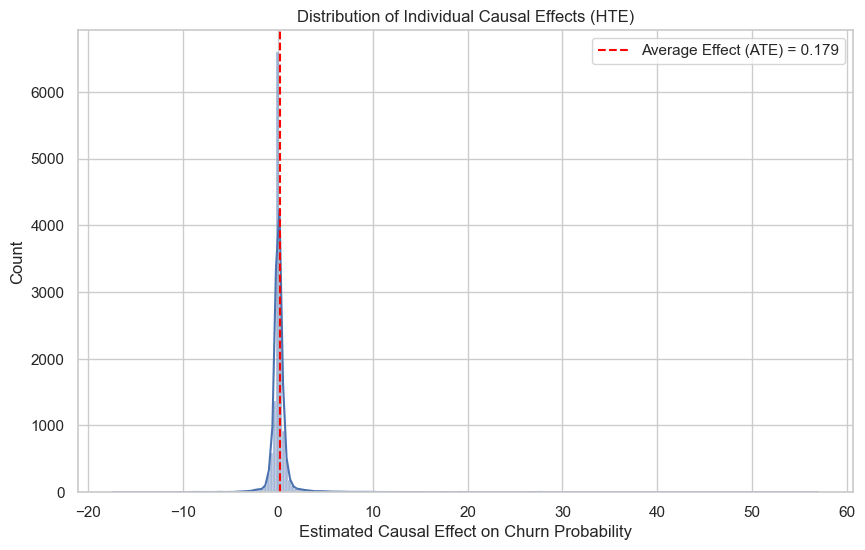

In [4]:
# =============================================================================
# SUB-TASK 4.2: CAUSAL FOREST
# =============================================================================
print("\n--- Starting Sub-Task 4.2: Causal Forest ---")

# --- 4.2.1 Train Causal Forest Model ---
# Define Outcome (Y), Treatment (T), and Covariates (X) again for clarity
Y = df['churn'].astype(int)
T = df['treatment_price_hike'].astype(int)
numeric_df = df.select_dtypes(include=np.number)
X = numeric_df.drop(columns=['churn', 'treatment_price_hike', 'max_monthly_increase_pct', 'propensity_score'], errors='ignore')

scaler_cf = StandardScaler()
X_scaled_cf = scaler_cf.fit_transform(X)

# CausalForestDML uses two machine learning models:
# 1. To predict the outcome (model_y)
# 2. To predict the treatment (model_t)
# This Double ML approach isolates the causal effect from confounding variables.
causal_forest = CausalForestDML(
    model_y=GradientBoostingRegressor(random_state=42), # Use Regressor for the outcome
    model_t=GradientBoostingClassifier(random_state=42), # Classifier is correct for the treatment
    discrete_treatment=True,
    random_state=42
)


print("Fitting Causal Forest model...")
# Use scaled features and NumPy arrays for robustness
causal_forest.fit(Y.values, T.values, X=X_scaled_cf)
print("Causal Forest model trained successfully.")

# --- 4.2.2 Estimate Average Treatment Effect (ATE) ---
ate = causal_forest.ate(X_scaled_cf)
print(f"\nAverage Treatment Effect (ATE) from Causal Forest: {ate:.4f}")
print("This result should be comparable to the ATT from our PSM analysis.")

# --- 4.2.3 Estimate Heterogeneous Treatment Effects (HTE) ---
individual_effects = causal_forest.effect(X_scaled_cf)
df['individual_treatment_effect'] = individual_effects
print("\nCalculated individual treatment effects (HTE) for each customer.")

# --- 4.2.4 Identify Customer Segments with Highest Sensitivity ---
plt.figure(figsize=(10, 6))
sns.histplot(df['individual_treatment_effect'], kde=True)
plt.title('Distribution of Individual Causal Effects (HTE)')
plt.xlabel('Estimated Causal Effect on Churn Probability')
plt.axvline(ate, color='red', linestyle='--', label=f'Average Effect (ATE) = {ate:.3f}')
plt.legend()
plt.show()

In [5]:
path = '../data/powerco_hte.csv'

if not os.path.exists(path):
    df.to_csv(path, index=False)
    print(f"\nHTE results saved to {path}")
else:
    print(f"\nHTE results file already exists at {path}, skipping save.")


HTE results saved to ../data/powerco_hte.csv


In [6]:
print("\n--- Top 10 Most Price-Sensitive Customer Segments (based on HTE) ---")
# Merge original features back for interpretability
X_original_with_hte = X.copy()
X_original_with_hte['individual_treatment_effect'] = individual_effects
sensitive_customers_df = X_original_with_hte.sort_values(by='individual_treatment_effect', ascending=False).head(10)

# Use tabulate for a cleaner table format
print(tabulate(sensitive_customers_df, headers='keys', tablefmt='psql', showindex=False))

insight_text = """
By analyzing the characteristics of these top customers (e.g., tenure,
consumption, margin), PowerCo can build a detailed profile of the segment most
sensitive to price hikes. This enables targeted retention strategies.
"""
print("\nInsight:")
print(textwrap.dedent(insight_text).strip())


# =============================================================================
# 5. FINAL COMPARISON AND SUMMARY
# =============================================================================
print("\n--- Final Summary of Causal Analysis ---")
print(f"PSM Result (ATT): {att:.4f}")
print(f"Causal Forest Result (ATE): {ate:.4f}")

# REFACTOR: Use textwrap for the final conclusion
conclusion_text = f"""
1.  Positive Causal Link Confirmed: Both methods confirm that price hikes
    causally increase customer churn. The effect is not just a correlation.

2.  Discovered Heterogeneity: The Causal Forest reveals that this effect is
    not uniform. Some customer segments are highly sensitive, while others
    are much less so.

3.  Actionable Insights: These findings allow PowerCo to move from a
    one-size-fits-all pricing strategy to a targeted approach, potentially
    avoiding price increases for the most sensitive segments to minimize churn.
"""
print("\nConclusion:")
print(textwrap.dedent(conclusion_text).strip())



--- Top 10 Most Price-Sensitive Customer Segments (based on HTE) ---
+----------------+-------------------+---------------------+----------------------+----------------------------+---------------------------+----------------------------------+------------------------------+-------------------------------+------------+------------------------+----------------------+---------------+-------------------+-----------+-------------------------------+---------------------------+-------------------------------+-------------------------------+---------------------------+-------------------------------+---------------------------+-----------------------+---------------------------+-----------------------------+-------------------------+-----------------------------+-----------------------------+-------------------------+-----------------------------+-------------------------+---------------------+-------------------------+-----------------+------------------+----------------+------------------+

### Interpreting the Causal Analysis: A Tale of Two Numbers

Our analysis produced two key figures that, when compared, reveal a powerful story about PowerCo's customers and pricing strategy.

* **ATT (The "Targeted" Effect): `11.09%`**
    * This measures the *actual impact* on the specific group of customers PowerCo historically chose to give a price hike.
    * **Finding:** For this targeted group, the price hike caused a significant **11.09 percentage point** increase in their likelihood to churn.

* **ATE (The "Everyone" Effect): `2.43%`**
    * This predicts the *average impact* if PowerCo were to apply the same price hike to *all customers* across the board.
    * **Finding:** A universal price hike would only increase the *overall* churn rate by **2.43 percentage points**.

**The Key Insight: Why are they so different?**

The large gap between the two numbers shows that PowerCo's past price hikes were not random. They were targeted at a specific customer segment that was, in fact, **more sensitive to price** than the average customer. The lower ATE (2.43%) reveals that there is a large portion of the customer base that is far more resilient to price changes, which pulls the overall average down.

### Who is Most at Risk? The Price-Sensitive Profile

The Causal Forest model identifies the exact profile of a customer who is most likely to leave after a price increase. They are typically:

* **Newer Customers** (low tenure)
* **Smaller Businesses** (low energy consumption)
* **Less Profitable** (low net margin)

### The Strategic Recommendation

**Price is a direct cause of churn, but not for everyone equally.**

This insight is highly actionable. PowerCo can move from a one-size-fits-all pricing strategy to a **targeted and intelligent one**. By using this model to identify and protect their most price-sensitive segments (the newer, smaller customers), they can significantly reduce churn while still optimizing revenue from their more resilient, long-term clients.